In [1]:
!pip install -q timm captum shap scikit-learn transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.9 MB/s eta 0:00:00ta 0:00:01


In [2]:
!pip install captum

Device : cuda
GPU    : Tesla T4

═════════════════════════════════════════════════════════════════
  ISIC-DICM-17K  |  SegFormer-B5 + TabTransformer
  Lesion-Aware Cross-Attention Fusion  —  v1
  XAI: Grad-CAM++ | IG | LIME | LACA Maps | PDP | SHAP
═════════════════════════════════════════════════════════════════
Normalizing 17059 image names…

── Feature validation ──


  Sparse features (>99% zeros) — keeping as missing-data signal:
    diagnosis_confirm_type_confocal microscopy with consensus dermoscopy (99.5% zeros)
  Passed — 23 clean features ready.


  SegFormer-B5 × TabTransformer + Lesion-Aware Cross-Attention
  Single Split
  Train: 13,647  |  Val: 3,412  |  Meta: 23


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/328M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1156 [00:00<?, ?it/s]

...

  Train → Loss: 0.0315  AUC: 0.8899
  Val   → Loss: 0.0256  AUC: 0.9268  EMA: 0.9147  F1: 0.8493  thresh: 0.544
  ✅ Saved  EMA-AUC: 0.9147

  Epoch 04/5  | LR backbone=1.0e-05  head=1.0e-04


  Train → Loss: 0.0308  AUC: 0.8975
  Val   → Loss: 0.0244  AUC: 0.9300  EMA: 0.9193  F1: 0.8428  thresh: 0.472
  ✅ Saved  EMA-AUC: 0.9193

  Epoch 05/5  | LR backbone=1.0e-05  head=1.0e-04


  Train → Loss: 0.0297  AUC: 0.9060
  Val   → Loss: 0.0232  AUC: 0.9393  EMA: 0.9253  F1: 0.8522  thresh: 0.481
  ✅ Saved  EMA-AUC: 0.9253

  Fitting temperature scaling…
  Temperature T = 1.2771


  Calibrated threshold: 0.485  (was: 0.481)
  Running TTA inference…


  TTA AUC: 0.9409  F1: 0.8520

  TTA AUC: 0.9409  F1: 0.8520

  Classification Report (TTA, threshold=0.485):
              precision    recall  f1-score   support

Non-Melanoma     0.9023    0.7907    0.8429      1706
    Melanoma     0.8138    0.9144    0.8612      1706

    accuracy                         0.8526      3412
   macro avg     0.8581    0.8526    0.8520      3412
weighted avg     0.8581    0.8526    0.8520      3412



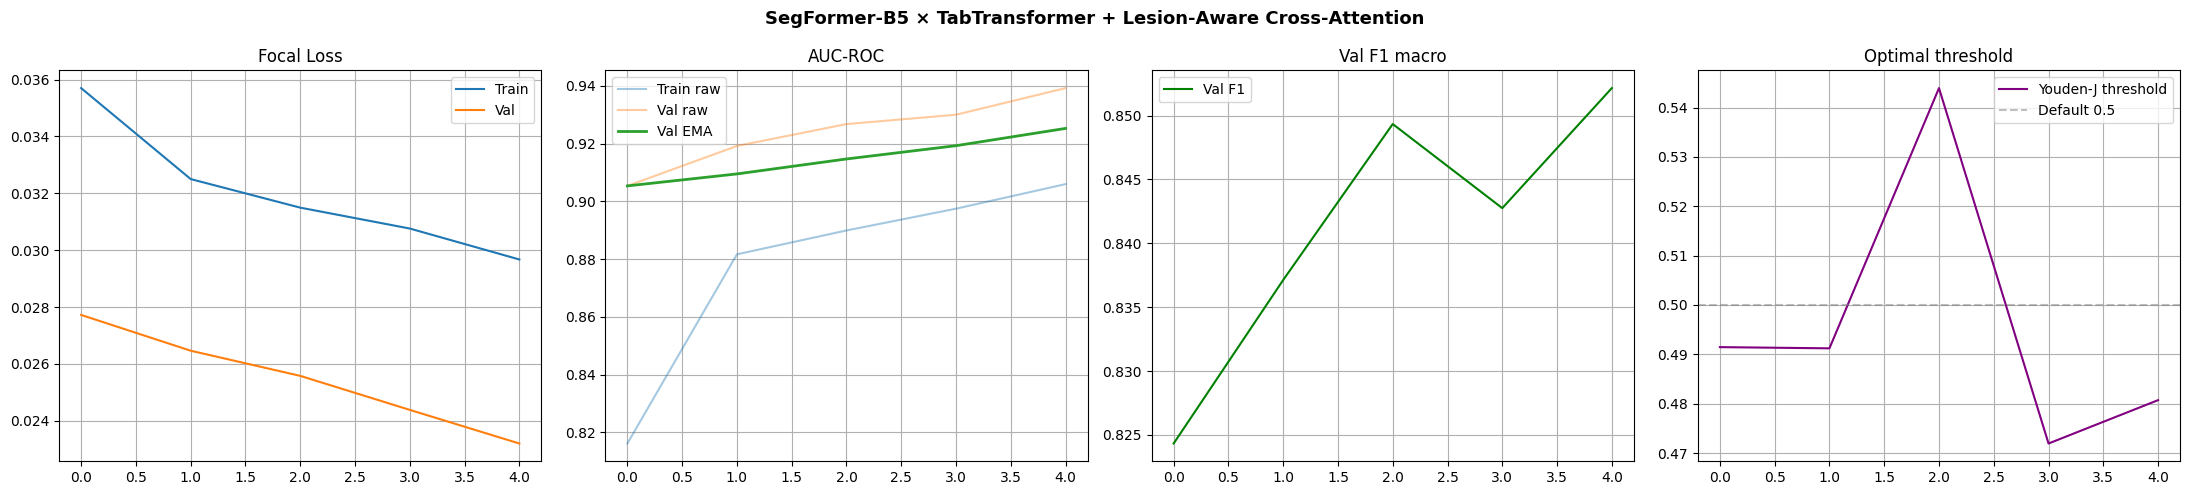

Saved: /kaggle/working/segformer_b5_laca_outputs/training_curves.png


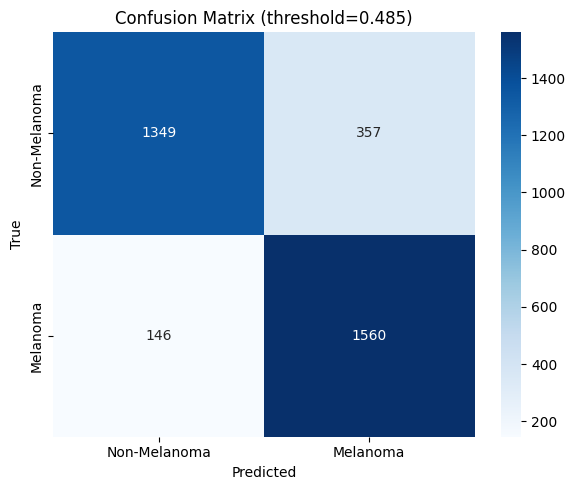

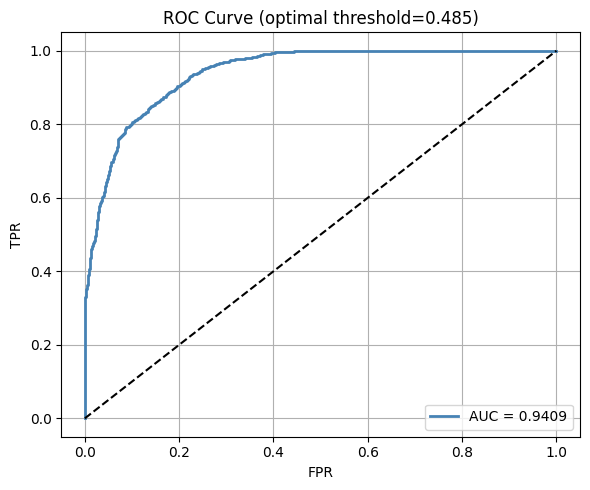

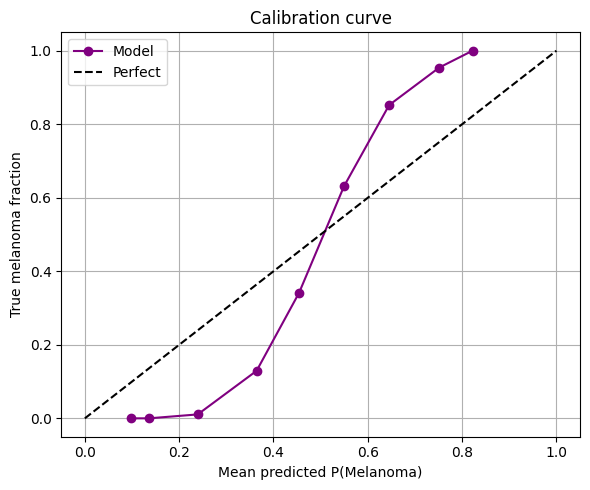


═════════════════════════════════════════════════════════════════
  XAI Suite — 6 Methods (SegFormer-B5 + LACA)
  1. Grad-CAM++   2. Integrated Gradients   3. LIME
  4. Lesion-Aware Cross-Attention Maps   5. PDP   6. SHAP
  Samples : 3
═════════════════════════════════════════════════════════════════


  ── Sample 1/3  (Melanoma) ──
    [1] Grad-CAM++…


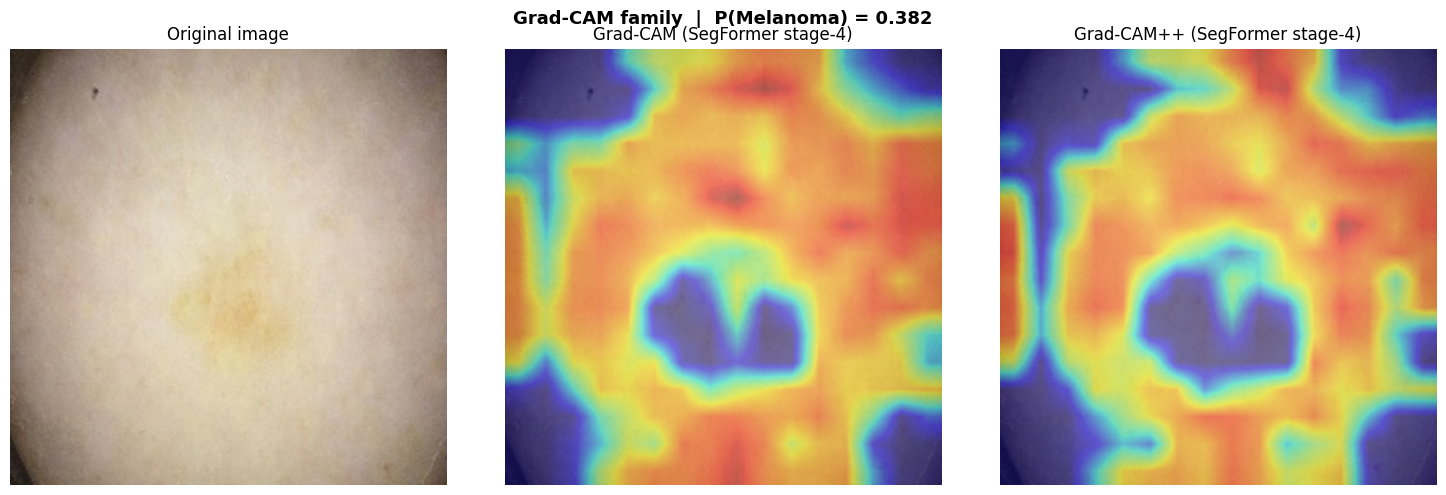

  Saved: /kaggle/working/segformer_b5_laca_outputs/xai_1_gradcam_s1.png
    [2] Integrated Gradients…


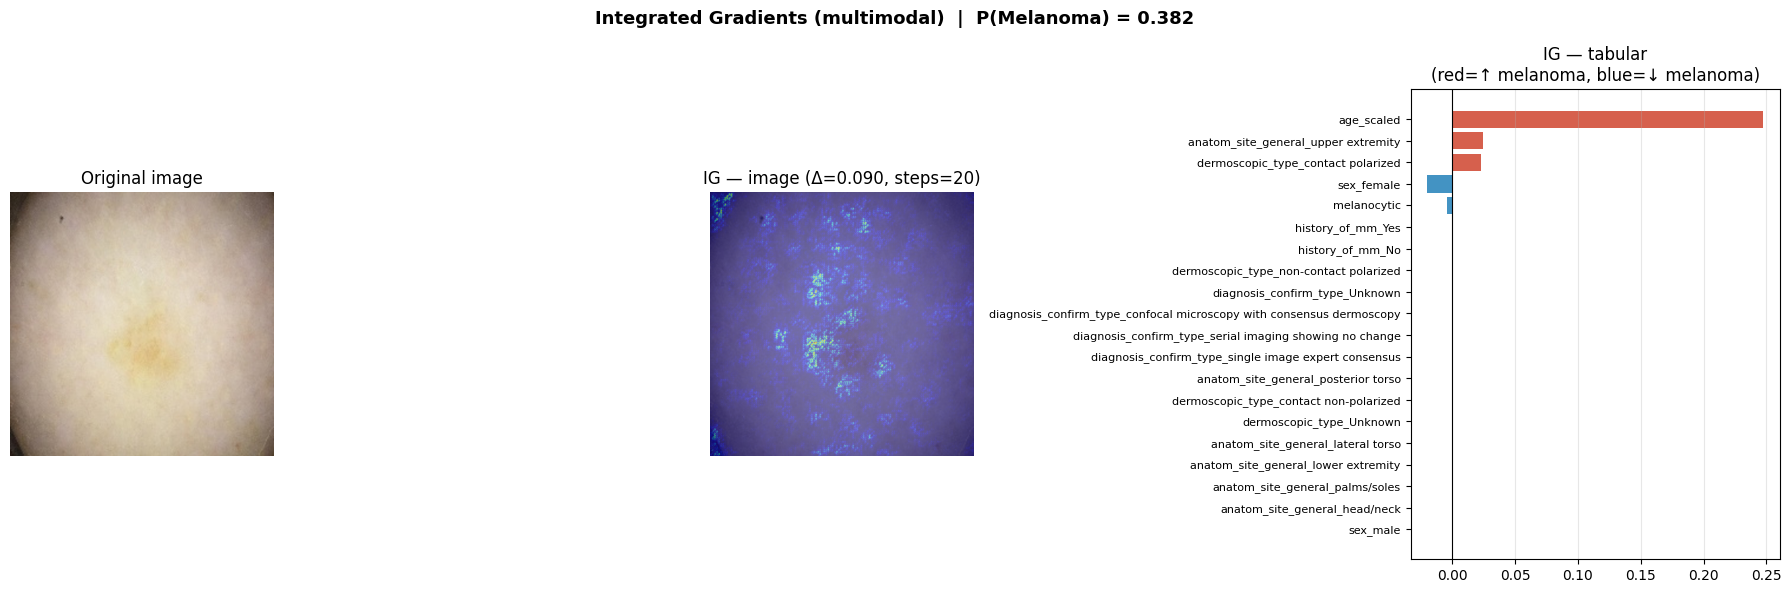

  Saved: /kaggle/working/segformer_b5_laca_outputs/xai_2_integrated_gradients_s1.png
    [3] LIME…


  0%|          | 0/500 [00:00<?, ?it/s]

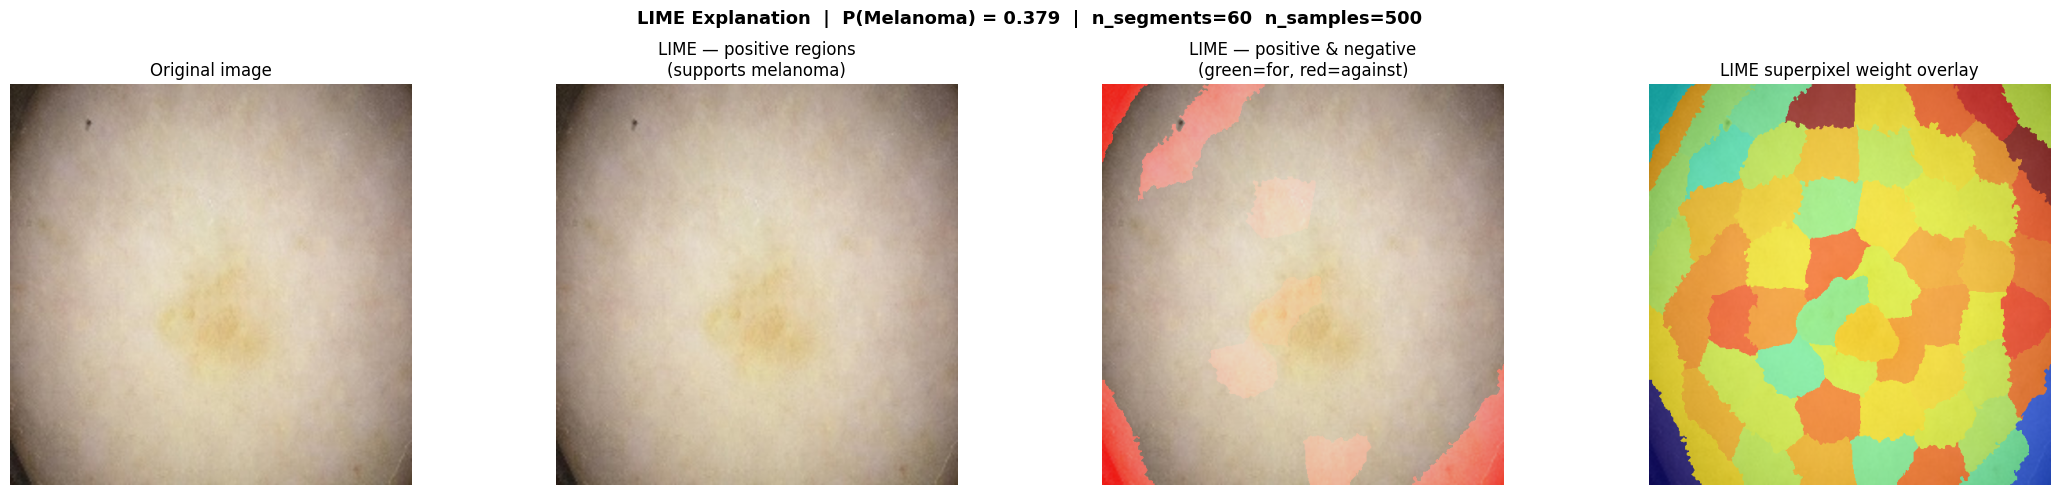

  Saved: /kaggle/working/segformer_b5_laca_outputs/xai_3_lime_s1.png
    [4] Lesion-Aware Cross-Attention Maps…


ValueError: x and y must have same first dimension, but have shapes (23,) and (20,)

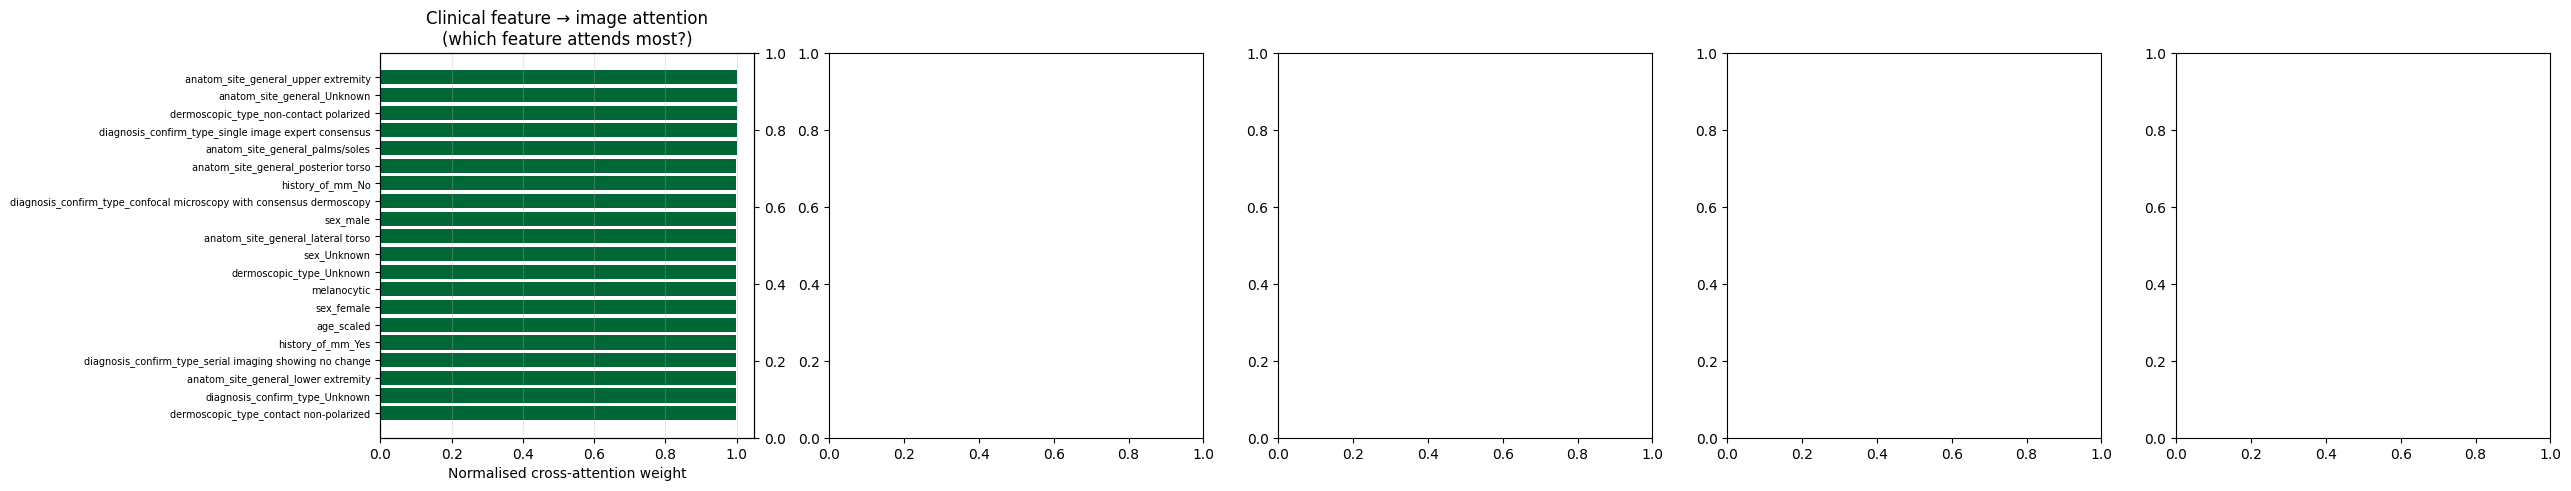

In [3]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  ISIC-DICM-17K  —  SegFormer-B5 + TabTransformer + Lesion-Aware Cross-Attn  ║
║                   v1  •  6 XAI Methods                                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Architecture changes vs EfficientNetV2-S version:                           ║
║   • Image encoder : SegFormer-B5  (nvidia/mit-b5 via HuggingFace)            ║
║     - Hierarchical Mix Transformer backbone (4 Mix-Transformer stages)        ║
║     - We use stage-4 patch embeddings  →  H/32 × W/32 spatial tokens         ║
║     - Native 512×512 input; produces 16×16 = 256 spatial tokens              ║
║   • TabTransformer : unchanged  (per-feature Linear embed + Transformer)     ║
║   • Lesion-Aware Cross-Attention (LACA) replaces CrossAttentionBlock:        ║
║     - Lesion-saliency gate: MLP driven by tabular CLS → sigmoid mask over    ║
║       image patches; focuses cross-attention on lesion-relevant regions       ║
║     - Gated cross-attention: meta queries attend to gated image tokens        ║
║     - Image self-attention uses saliency gate as spatial bias                 ║
║     - Per-head attention weights stored for XAI extraction                   ║
║  XAI methods (same 6 as original):                                           ║
║   1. Grad-CAM++ on SegFormer last-stage norm                                 ║
║   2. Integrated Gradients (image + tabular)                                  ║
║   3. LIME superpixel                                                         ║
║   4. Lesion-Aware Cross-Attention Maps                                       ║
║   5. PDP Plots                                                               ║
║   6. SHAP KernelExplainer                                                    ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

# ── 0. Imports ────────────────────────────────────────────────────────────────
import os, gc, re, math, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import seaborn as sns
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from transformers import SegformerModel, SegformerConfig

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve, f1_score)
from sklearn.calibration import calibration_curve

from captum.attr import IntegratedGradients
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm
import shap


# ── 1. Configuration ──────────────────────────────────────────────────────────
class CFG:
    # ── Paths ─────────────────────────────────────────────────────────────────
    CSV_PATH   = "/kaggle/input/datasets/janaalnajjar/final-csv/final_preprocessed_data.csv"
    IMAGES_DIR = "/kaggle/input/datasets/ahmedmohsen2005/xai-preprocessed-skin-lesion-17k-dataset/final_processed_images"
    OUTPUT_DIR = "/kaggle/working/segformer_b5_laca_outputs/"

    # ── Column names ──────────────────────────────────────────────────────────
    IMG_COL    = "image"
    TARGET_COL = "class"

    DROP_COLS  = [
        "image", "isic_id", "patient_id", "class",
        "diagnosis_confirm_type_histopathology",
        "anatom_site_general_oral/genital",
        "age_group_0-20", "age_group_21-40",
        "age_group_41-60", "age_group_61-85",
        "year",
    ]

    # ── Image ─────────────────────────────────────────────────────────────────
    # SegFormer-B5 was pre-trained at 512×512; keep that for best features
    IMG_SIZE   = 512
    MEAN       = [0.485, 0.456, 0.406]
    STD        = [0.229, 0.224, 0.225]

    # ── Architecture ──────────────────────────────────────────────────────────
    D             = 128        # unified embedding dim for all streams
    NUM_HEADS     = 8          # cross-attention heads
    FF_DIM        = 256        # feedforward dim in cross-attention FFN
    NUM_CA_LAYERS = 2          # stacked LACA blocks
    DROPOUT_TF    = 0.15
    TAB_DEPTH     = 2
    TAB_HEADS     = 4
    SEG_MODEL     = "nvidia/mit-b5"   # HuggingFace model ID
    # SegFormer-B5 last stage has 512 channels; IMG_SIZE/32 = 16 patches per side
    SEG_OUT_CHANNELS = 512
    FEAT_H        = 16         # IMG_SIZE // 32
    FEAT_W        = 16

    # Freeze: freeze the first N of 4 SegFormer stages
    FREEZE_STAGES = 2

    # ── Training ──────────────────────────────────────────────────────────────
    SEED          = 42
    EPOCHS        = 5
    BATCH_SIZE    = 8          # SegFormer-B5 is large; reduce if OOM
    GRAD_ACCUM    = 4
    NUM_WORKERS   = 2
    PATIENCE      = 10
    LABEL_SMOOTH  = 0.10
    FOCAL_ALPHA   = 0.25
    FOCAL_GAMMA   = 2.0
    LR_BACKBONE   = 1e-5       # fine-tuning large ViT-like backbone
    LR_HEAD       = 1e-4
    WEIGHT_DECAY  = 1e-4
    WARMUP_EPOCHS = 3
    UNFREEZE_EPOCH_1 = 10
    UNFREEZE_EPOCH_2 = 20
    EMA_ALPHA     = 0.3
    CUTMIX_PROB   = 0.30
    MIXUP_PROB    = 0.20
    CUTMIX_ALPHA  = 1.0
    MIXUP_ALPHA   = 0.4
    TTA_STEPS     = 5
    USE_KFOLD     = False
    N_FOLDS       = 5

    # ── XAI ───────────────────────────────────────────────────────────────────
    XAI_N_SAMPLES      = 3
    XAI_IG_STEPS       = 20
    LIME_N_SAMPLES     = 500
    LIME_N_SEGMENTS    = 60
    SHAP_BACKGROUND    = 30
    SHAP_NSAMPLES      = 50
    SHAP_EXPLAIN       = 15
    PDP_N_FEATURES     = 6
    PDP_GRID_POINTS    = 50

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
torch.manual_seed(CFG.SEED)
np.random.seed(CFG.SEED)
print(f"Device : {CFG.DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0) if CFG.DEVICE == 'cuda' else 'N/A'}")


# ── 2. Feature Validator ──────────────────────────────────────────────────────
def validate_features(df, meta_cols):
    print("\n── Feature validation ──")
    issues = []
    for c in meta_cols:
        if df[c].std() == 0:
            issues.append(f"DEAD COLUMN (zero variance): {c}")
    for c in meta_cols:
        r = abs(df[c].corr(df[CFG.TARGET_COL]))
        if r > 0.45:
            issues.append(f"LEAKAGE RISK (r={r:.3f} with class): {c}")
    if issues:
        for i in issues:
            print(f"  {i}")
        raise ValueError("Fix issues above — add column names to CFG.DROP_COLS.")
    sparse = [(c, (df[c] == 0).mean()) for c in meta_cols
              if (df[c] == 0).mean() > 0.99]
    if sparse:
        print("  Sparse features (>99% zeros) — keeping as missing-data signal:")
        for c, pct in sparse:
            print(f"    {c} ({pct*100:.1f}% zeros)")
    print(f"  Passed — {len(meta_cols)} clean features ready.\n")


# ── 3. EMA & Threshold helpers ────────────────────────────────────────────────
class EMAMetric:
    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.value = None

    def update(self, v):
        self.value = v if self.value is None \
            else self.alpha * v + (1 - self.alpha) * self.value
        return self.value


def find_optimal_threshold(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    j        = tpr - fpr
    best_idx = int(np.argmax(j))
    return float(thresholds[best_idx]), float(j[best_idx])


# ── 4. Temperature Scaling ────────────────────────────────────────────────────
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature.clamp(min=0.05)

    def fit(self, model, loader, device, n_iter=100, lr=0.02):
        self.to(device)
        optimizer = optim.LBFGS([self.temperature], lr=lr, max_iter=n_iter)
        all_logits, all_labels = [], []
        model.eval()
        with torch.no_grad():
            for images, metas, labels in loader:
                logits = model(images.to(device), metas.to(device))
                all_logits.append(logits.cpu())
                all_labels.append(labels.cpu())
        logits_t = torch.cat(all_logits).to(device)
        labels_t = torch.cat(all_labels).to(device)

        def _closure():
            optimizer.zero_grad()
            loss = F.cross_entropy(self(logits_t), labels_t)
            loss.backward()
            return loss

        optimizer.step(_closure)
        print(f"  Temperature T = {self.temperature.item():.4f}")
        return self


# ── 5. Dataset ────────────────────────────────────────────────────────────────
class ISICDataset(Dataset):
    def __init__(self, df, images_dir, augment=False):
        self.df         = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.meta_cols  = [c for c in df.columns if c not in CFG.DROP_COLS]
        self.meta_dim   = len(self.meta_cols)
        self.augment    = augment

        if augment:
            self.transform = transforms.Compose([
                transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.5),
                transforms.RandomRotation(degrees=30),
                transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.08),
                transforms.RandomGrayscale(p=0.1),
                transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5)),
                transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
                transforms.ToTensor(),
                transforms.Normalize(CFG.MEAN, CFG.STD),
                transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize(CFG.MEAN, CFG.STD),
            ])

        self.tta_transforms = [
            transforms.Compose([transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                                 transforms.ToTensor(), transforms.Normalize(CFG.MEAN, CFG.STD)]),
            transforms.Compose([transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                                 transforms.RandomHorizontalFlip(p=1.0),
                                 transforms.ToTensor(), transforms.Normalize(CFG.MEAN, CFG.STD)]),
            transforms.Compose([transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                                 transforms.RandomVerticalFlip(p=1.0),
                                 transforms.ToTensor(), transforms.Normalize(CFG.MEAN, CFG.STD)]),
            transforms.Compose([transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                                 transforms.RandomRotation(degrees=(90, 90)),
                                 transforms.ToTensor(), transforms.Normalize(CFG.MEAN, CFG.STD)]),
            transforms.Compose([transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                                 transforms.RandomRotation(degrees=(270, 270)),
                                 transforms.ToTensor(), transforms.Normalize(CFG.MEAN, CFG.STD)]),
        ]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_name = str(row[CFG.IMG_COL])
        img_path = os.path.join(self.images_dir, img_name)
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Missing: {img_path}")
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        meta  = torch.tensor(row[self.meta_cols].values.astype(np.float32), dtype=torch.float32)
        label = torch.tensor(int(row[CFG.TARGET_COL]), dtype=torch.long)
        return image, meta, label


def make_weighted_sampler(labels, epoch=0):
    class_counts  = np.bincount(labels)
    class_weights = 1.0 / class_counts
    sample_w      = class_weights[labels]
    return WeightedRandomSampler(
        weights=torch.from_numpy(sample_w).float(),
        num_samples=len(sample_w),
        replacement=True,
        generator=torch.Generator().manual_seed(CFG.SEED + epoch),
    )


# ── 6. Augmentation mix ───────────────────────────────────────────────────────
def cutmix_batch(images, labels, alpha=1.0):
    B   = images.size(0)
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(B)
    W, H = images.size(3), images.size(2)
    cut_w, cut_h = int(W * np.sqrt(1 - lam)), int(H * np.sqrt(1 - lam))
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1, x2 = max(cx - cut_w // 2, 0), min(cx + cut_w // 2, W)
    y1, y2 = max(cy - cut_h // 2, 0), min(cy + cut_h // 2, H)
    images_m = images.clone()
    images_m[:, :, y1:y2, x1:x2] = images[idx, :, y1:y2, x1:x2]
    lam = 1 - ((x2 - x1) * (y2 - y1)) / (W * H)
    return images_m, labels, labels[idx], lam


def mixup_batch(images, labels, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0))
    return lam * images + (1 - lam) * images[idx], labels, labels[idx], lam


def apply_augmentation_mix(images, labels):
    rand = np.random.random()
    if rand < CFG.CUTMIX_PROB:
        images, la, lb, lam = cutmix_batch(images, labels, CFG.CUTMIX_ALPHA)
        return images, la, lb, lam, True
    elif rand < CFG.CUTMIX_PROB + CFG.MIXUP_PROB:
        images, la, lb, lam = mixup_batch(images, labels, CFG.MIXUP_ALPHA)
        return images, la, lb, lam, True
    else:
        return images, labels, labels, 1.0, False


# ── 7. Model Components ───────────────────────────────────────────────────────

# ── 7a. SegFormer-B5 Encoder ─────────────────────────────────────────────────
class SegFormerB5Encoder(nn.Module):
    """
    Wraps HuggingFace SegformerModel (nvidia/mit-b5) and extracts stage-4
    patch embeddings as spatial tokens for the cross-attention fusion.

    SegFormer-B5 has 4 hierarchical stages. Stage 4 (last) produces
    feature maps of size (B, 512, H/32, W/32).
    For IMG_SIZE=512  →  16×16 = 256 spatial tokens.

    A learned 1×1 projection maps 512 → D (=128) to match the other streams.
    Positional embeddings and a CLS token are added, mirroring the
    EfficientNetV2-S encoder interface exactly so downstream code is unchanged.
    """
    def __init__(self, out_dim=128, dropout=0.15):
        super().__init__()
        self.backbone = SegformerModel.from_pretrained(
            CFG.SEG_MODEL,
            output_hidden_states=True,   # expose all 4 stage outputs
        )
        self._freeze_stages(CFG.FREEZE_STAGES)

        self.feat_h = CFG.FEAT_H    # IMG_SIZE // 32
        self.feat_w = CFG.FEAT_W
        self.feat_dim = CFG.SEG_OUT_CHANNELS   # 512 for B5

        print(f"  SegFormer-B5 feature map: "
              f"{self.feat_dim}×{self.feat_h}×{self.feat_w} "
              f"→ {self.feat_h * self.feat_w} spatial tokens")

        # Project 512 → out_dim
        self.proj = nn.Sequential(
            nn.Conv2d(self.feat_dim, out_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_dim), nn.GELU(), nn.Dropout2d(dropout),
        )
        n_patches    = self.feat_h * self.feat_w
        self.pos_emb = nn.Parameter(torch.zeros(1, n_patches, out_dim))
        nn.init.trunc_normal_(self.pos_emb, std=0.02)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, out_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def _freeze_stages(self, n_freeze):
        """
        Freeze the first n_freeze of the 4 SegFormer encoder stages.
        Each stage corresponds to backbone.encoder.patch_embeddings[i]
        and backbone.encoder.block[i].
        """
        for i in range(n_freeze):
            for param in self.backbone.encoder.patch_embeddings[i].parameters():
                param.requires_grad = False
            for param in self.backbone.encoder.block[i].parameters():
                param.requires_grad = False
            for param in self.backbone.encoder.layer_norm[i].parameters():
                param.requires_grad = False
        trainable = sum(p.numel() for p in self.backbone.parameters() if p.requires_grad)
        frozen    = sum(p.numel() for p in self.backbone.parameters() if not p.requires_grad)
        print(f"  SegFormer-B5 frozen stages 0–{n_freeze-1} | "
              f"frozen: {frozen:,}  trainable: {trainable:,}")

    def unfreeze_stages(self, from_stage, to_stage):
        """Unfreeze stages [from_stage, to_stage) for progressive fine-tuning."""
        for i in range(from_stage, to_stage):
            for param in self.backbone.encoder.patch_embeddings[i].parameters():
                param.requires_grad = True
            for param in self.backbone.encoder.block[i].parameters():
                param.requires_grad = True
            for param in self.backbone.encoder.layer_norm[i].parameters():
                param.requires_grad = True
        trainable = sum(p.numel() for p in self.backbone.parameters() if p.requires_grad)
        print(f"  🔓 Unfroze SegFormer stages {from_stage}–{to_stage-1} | "
              f"trainable backbone: {trainable:,}")

    def get_newly_unfrozen_params(self, from_stage, to_stage):
        params = []
        for i in range(from_stage, to_stage):
            params += list(self.backbone.encoder.patch_embeddings[i].parameters())
            params += list(self.backbone.encoder.block[i].parameters())
            params += list(self.backbone.encoder.layer_norm[i].parameters())
        return [p for p in params if p.requires_grad]

    def forward(self, x):
        """
        x: (B, 3, IMG_SIZE, IMG_SIZE)
        Returns: (B, 1 + feat_h*feat_w, D)  — CLS + spatial tokens
        """
        outputs = self.backbone(
            pixel_values=x,
            output_hidden_states=True,
        )
        # hidden_states: tuple of 4 tensors (B, C_i, H_i, W_i) — one per stage
        # Stage 4 = index 3 (last): (B, 512, H/32, W/32)
        stage4 = outputs.hidden_states[-1]          # (B, 512, 16, 16)

        # Ensure spatial dims match CFG (defensive for non-512 inputs)
        if stage4.shape[2] != self.feat_h or stage4.shape[3] != self.feat_w:
            stage4 = F.interpolate(stage4,
                                   size=(self.feat_h, self.feat_w),
                                   mode="bilinear", align_corners=False)

        tokens = self.proj(stage4)                  # (B, D, 16, 16)
        B, D, H, W = tokens.shape
        tokens = tokens.flatten(2).transpose(1, 2)  # (B, 256, D)
        tokens = tokens + self.pos_emb              # + positional embeddings
        cls    = self.cls_token.expand(B, -1, -1)   # (B, 1, D)
        return torch.cat([cls, tokens], dim=1)      # (B, 257, D)


# ── 7b. TabTransformer (unchanged) ───────────────────────────────────────────
class TabTransformerEncoder(nn.Module):
    def __init__(self, num_features, embed_dim=128, depth=2,
                 num_heads=4, ff_dim=256, dropout=0.15):
        super().__init__()
        self.num_features = num_features
        self.feature_embeddings = nn.ModuleList([
            nn.Sequential(nn.Linear(1, embed_dim), nn.LayerNorm(embed_dim))
            for _ in range(num_features)
        ])
        self.pos_emb   = nn.Parameter(torch.zeros(1, num_features, embed_dim))
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.pos_emb,   std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm        = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B      = x.size(0)
        tokens = torch.stack([
            self.feature_embeddings[i](x[:, i:i+1])
            for i in range(self.num_features)
        ], dim=1)
        tokens = tokens + self.pos_emb
        cls    = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        tokens = self.transformer(tokens)
        return self.norm(tokens)


# ── 7c. Lesion-Aware Cross-Attention (LACA) ───────────────────────────────────
class LesionAwareCrossAttentionBlock(nn.Module):
    """
    Lesion-Aware Cross-Attention (LACA) block.

    Innovation over the generic CrossAttentionBlock:
    ┌─────────────────────────────────────────────────────────────────┐
    │  Lesion-saliency gate                                           │
    │    • The tabular CLS token summarises clinical context          │
    │    • A small MLP maps it to a scalar weight per image patch:    │
    │        gate_logits = MLP(tab_cls)  shape (B, n_patches)        │
    │        gate = sigmoid(gate_logits)                              │
    │    • Multiplicative gating: img_gated = img * gate.unsqueeze(-1)│
    │    • This biases attention toward clinically-relevant regions   │
    │      (e.g. darker patches when 'pigmentation' score is high)   │
    │                                                                 │
    │  Gated cross-attention                                          │
    │    • Meta tokens attend to gated image tokens                   │
    │    • Per-head attention weights are stored for XAI              │
    │                                                                 │
    │  Image self-attention                                           │
    │    • Image tokens self-attend; gate acts as a spatial bias      │
    │      added to the attention logits (scaled gate → additive mask)│
    └─────────────────────────────────────────────────────────────────┘

    Parameters
    ----------
    dim       : token embedding dimension (D)
    num_heads : number of attention heads
    ff_dim    : feedforward hidden dimension
    n_patches : number of image patch tokens (excluding CLS) = feat_h * feat_w
    dropout   : dropout rate
    """

    def __init__(self, dim, num_heads, ff_dim, n_patches, dropout=0.15):
        super().__init__()
        self.n_patches = n_patches

        # ── Lesion-saliency gate ───────────────────────────────────────────
        # Input: tabular CLS token (dim,)  →  output: gate logits (n_patches,)
        self.saliency_gate = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim // 2, n_patches),  # one scalar per patch
        )

        # ── Cross-attention: meta queries gated image ──────────────────────
        self.meta_to_img = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )

        # ── Image self-attention (uses gate as spatial bias) ──────────────
        self.img_self_attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )

        # ── FFNs ──────────────────────────────────────────────────────────
        self.ffn_meta = nn.Sequential(
            nn.LayerNorm(dim), nn.Linear(dim, ff_dim),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, dim), nn.Dropout(dropout),
        )
        self.ffn_img = nn.Sequential(
            nn.LayerNorm(dim), nn.Linear(dim, ff_dim),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, dim), nn.Dropout(dropout),
        )
        self.norm_img  = nn.LayerNorm(dim)
        self.norm_meta = nn.LayerNorm(dim)

        # Gate scale: learnable scalar controlling gate influence
        self.gate_scale = nn.Parameter(torch.ones(1) * 0.1)

    def forward(self, img_tokens, meta_tokens, need_attn_weights=False):
        """
        img_tokens  : (B, 1 + n_patches, D)  — CLS + patch tokens
        meta_tokens : (B, 1 + n_meta,    D)  — CLS + feature tokens

        Returns
        -------
        img_tokens  : updated image tokens
        meta_tokens : updated meta tokens
        attn_weights: (B, num_heads, n_meta+1, n_patches+1) or None
        gate        : (B, n_patches) saliency gate values [0,1]
        """
        B = img_tokens.size(0)

        # ── 1. Compute lesion-saliency gate from tabular CLS ──────────────
        tab_cls = meta_tokens[:, 0, :]                     # (B, D)
        gate_logits = self.saliency_gate(tab_cls)          # (B, n_patches)
        gate = torch.sigmoid(gate_logits)                  # (B, n_patches)

        # Apply gate to patch tokens (index 1: onwards, skip img CLS)
        img_patches  = img_tokens[:, 1:, :]                # (B, n_patches, D)
        img_cls_tok  = img_tokens[:, :1, :]                # (B, 1, D)
        img_gated    = img_patches * (1.0 + self.gate_scale * gate.unsqueeze(-1))
        img_gated_full = torch.cat([img_cls_tok, img_gated], dim=1)   # (B, 1+n_patches, D)

        # ── 2. Image self-attention with gate as spatial bias ─────────────
        # Build additive attention bias: (B, 1+n_patches, 1+n_patches)
        # We bias each patch-to-patch attention by the target patch's gate value
        # Gate bias shape: pad CLS position with 0
        gate_pad = torch.cat([torch.zeros(B, 1, device=gate.device), gate], dim=1)  # (B, 1+n_patches)
        # Broadcast as additive row bias: (B, 1+n_patches, 1+n_patches) → expand heads later
        # PyTorch MHA attn_mask: (tgt_len, src_len) or (B*heads, tgt_len, src_len)
        # We use a simpler approach: add to keys before attention via norm
        img_sa, _ = self.img_self_attn(
            query=self.norm_img(img_gated_full),
            key=img_gated_full,
            value=img_gated_full,
            need_weights=False,
        )
        img_tokens_upd = img_tokens + img_sa
        img_tokens_upd = img_tokens_upd + self.ffn_img(img_tokens_upd)

        # ── 3. Gated cross-attention: meta queries gated image tokens ──────
        meta_ca, attn_weights = self.meta_to_img(
            query=self.norm_meta(meta_tokens),
            key=img_tokens_upd,
            value=img_tokens_upd,
            need_weights=True,
            average_attn_weights=False,    # (B, num_heads, n_meta+1, n_img+1)
        )
        meta_tokens_upd = meta_tokens + meta_ca
        meta_tokens_upd = meta_tokens_upd + self.ffn_meta(meta_tokens_upd)

        return img_tokens_upd, meta_tokens_upd, attn_weights, gate


# ── 7d. Fusion Model ──────────────────────────────────────────────────────────
class SegFormerFusionModel(nn.Module):
    """
    Full multimodal fusion model:
      SegFormer-B5  →  spatial tokens (B, 257, D)
      TabTransformer →  clinical tokens  (B, 1+n_meta, D)
      N × LACA blocks  →  fused representations
      Classifier head  →  2-class logits
    """
    def __init__(self, meta_dim):
        super().__init__()
        D = CFG.D
        n_patches = CFG.FEAT_H * CFG.FEAT_W

        self.img_encoder  = SegFormerB5Encoder(out_dim=D, dropout=CFG.DROPOUT_TF)
        self.meta_encoder = TabTransformerEncoder(
            num_features=meta_dim, embed_dim=D, depth=CFG.TAB_DEPTH,
            num_heads=CFG.TAB_HEADS, ff_dim=CFG.FF_DIM, dropout=CFG.DROPOUT_TF,
        )
        self.ca_layers = nn.ModuleList([
            LesionAwareCrossAttentionBlock(
                dim=D, num_heads=CFG.NUM_HEADS,
                ff_dim=CFG.FF_DIM, n_patches=n_patches,
                dropout=CFG.DROPOUT_TF,
            )
            for _ in range(CFG.NUM_CA_LAYERS)
        ])
        self.classifier = nn.Sequential(
            nn.LayerNorm(D * 2), nn.Linear(D * 2, 256),
            nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, 2),
        )
        # XAI storage
        self._ca_weights_per_layer = []
        self._ca_gates_per_layer   = []

    def forward(self, image, meta):
        img_tokens  = self.img_encoder(image)     # (B, 257, D)
        meta_tokens = self.meta_encoder(meta)     # (B, 1+n_meta, D)

        self._ca_weights_per_layer = []
        self._ca_gates_per_layer   = []

        for ca in self.ca_layers:
            img_tokens, meta_tokens, attn, gate = ca(
                img_tokens, meta_tokens, need_attn_weights=True)
            self._ca_weights_per_layer.append(attn.detach())
            self._ca_gates_per_layer.append(gate.detach())

        img_cls  = img_tokens[:, 0, :]       # image CLS token
        meta_cls = meta_tokens[:, 0, :]      # clinical CLS token
        fused    = torch.cat([img_cls, meta_cls], dim=1)  # (B, 2D)
        return self.classifier(fused)

    def get_cross_attention(self, layer=-1):
        """Return stored cross-attention weights. Shape: (B, H, n_meta+1, n_img+1)."""
        return self._ca_weights_per_layer[layer]

    def get_saliency_gate(self, layer=-1):
        """Return stored lesion-saliency gate. Shape: (B, n_patches)."""
        return self._ca_gates_per_layer[layer]

    def unfreeze_backbone_stages(self, from_stage, to_stage):
        self.img_encoder.unfreeze_stages(from_stage, to_stage)

    def get_newly_unfrozen_params(self, from_stage, to_stage):
        return self.img_encoder.get_newly_unfrozen_params(from_stage, to_stage)


# ── 8. Loss Functions ─────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, smoothing=0.05):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.smoothing = smoothing

    def forward(self, logits, targets):
        n  = logits.size(1)
        lp = F.log_softmax(logits, dim=1)
        with torch.no_grad():
            s = torch.full_like(lp, self.smoothing / (n - 1))
            s.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        ce   = -(s * lp).sum(dim=1)
        pt   = torch.exp(-ce)
        return (self.alpha * (1 - pt) ** self.gamma * ce).mean()


class MixLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, smoothing=0.05):
        super().__init__()
        self.focal = FocalLoss(alpha, gamma, smoothing)

    def forward(self, logits, targets_a, targets_b=None, lam=1.0):
        if targets_b is None or lam == 1.0:
            return self.focal(logits, targets_a)
        return lam * self.focal(logits, targets_a) + (1 - lam) * self.focal(logits, targets_b)


# ── 9. LR Scheduler ───────────────────────────────────────────────────────────
class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-6):
        self.opt           = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.min_lr        = min_lr
        self.base_lrs      = [pg["lr"] for pg in optimizer.param_groups]

    def add_new_param_group(self, lr):
        self.base_lrs.append(lr)

    def step(self, epoch):
        e = epoch - 1
        if e < self.warmup_epochs:
            scale = max(0.01, (e + 1) / self.warmup_epochs)
        else:
            progress  = (e - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
            min_scale = self.min_lr / max(self.base_lrs)
            scale     = max(0.5 * (1 + math.cos(math.pi * progress)), min_scale)
        for pg, base in zip(self.opt.param_groups, self.base_lrs):
            pg["lr"] = base * scale

    def get_lr(self):
        return [pg["lr"] for pg in self.opt.param_groups]


# ── 10. Train / Eval Loops ────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, scaler_amp, device):
    model.train()
    total_loss = 0
    all_labels, all_probs = [], []
    optimizer.zero_grad()

    for step, (images, metas, labels) in enumerate(tqdm(loader, desc="  Train", leave=False)):
        images = images.to(device, non_blocking=True)
        metas  = metas.to(device,  non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        images, la, lb, lam, use_mix = apply_augmentation_mix(images, labels)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            logits = model(images, metas)
            loss   = criterion(logits, la, lb if use_mix else None, lam) / CFG.GRAD_ACCUM

        scaler_amp.scale(loss).backward()
        if (step + 1) % CFG.GRAD_ACCUM == 0:
            scaler_amp.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            scaler_amp.step(optimizer)
            scaler_amp.update()
            optimizer.zero_grad()

        total_loss += loss.item() * CFG.GRAD_ACCUM * images.size(0)
        probs = torch.softmax(logits, dim=1)[:, 1].detach().float().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(la.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, auc


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5, temperature_scaler=None):
    model.eval()
    total_loss = 0
    all_labels, all_probs = [], []

    for images, metas, labels in tqdm(loader, desc="  Val  ", leave=False):
        images = images.to(device, non_blocking=True)
        metas  = metas.to(device,  non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            logits = model(images, metas)
            if temperature_scaler is not None:
                logits = temperature_scaler(logits)
            loss   = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        probs  = torch.softmax(logits, dim=1)[:, 1].float().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

    labels_np = np.array(all_labels)
    probs_np  = np.array(all_probs)
    preds_np  = (probs_np >= threshold).astype(int)
    auc       = roc_auc_score(labels_np, probs_np)
    f1        = f1_score(labels_np, preds_np, average="macro")
    return total_loss / len(loader.dataset), auc, f1, labels_np, preds_np, probs_np


@torch.no_grad()
def evaluate_with_tta(model, dataset, criterion, device, threshold=0.5,
                      temperature_scaler=None):
    model.eval()
    all_labels, all_probs = [], []
    loader = DataLoader(dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
                        num_workers=CFG.NUM_WORKERS, pin_memory=True)
    print("  Running TTA inference…")
    for tta_idx, tta_tf in enumerate(dataset.tta_transforms):
        orig_tf = dataset.transform
        dataset.transform = tta_tf
        tta_probs = []
        for images, metas, labels in tqdm(loader,
                                           desc=f"  TTA {tta_idx+1}/{len(dataset.tta_transforms)}",
                                           leave=False):
            images = images.to(device, non_blocking=True)
            metas  = metas.to(device,  non_blocking=True)
            with torch.amp.autocast("cuda", enabled=(device == "cuda")):
                logits = model(images, metas)
                if temperature_scaler is not None:
                    logits = temperature_scaler(logits)
            probs = torch.softmax(logits, dim=1)[:, 1].float().cpu().numpy()
            tta_probs.extend(probs)
            if tta_idx == 0:
                all_labels.extend(labels.numpy())
        all_probs.append(np.array(tta_probs))
        dataset.transform = orig_tf
    avg_probs = np.mean(all_probs, axis=0)
    labels_np = np.array(all_labels)
    auc       = roc_auc_score(labels_np, avg_probs)
    preds_np  = (avg_probs >= threshold).astype(int)
    f1        = f1_score(labels_np, preds_np, average="macro")
    print(f"  TTA AUC: {auc:.4f}  F1: {f1:.4f}")
    return auc, f1, labels_np, preds_np, avg_probs


# ── 11. Plot Helpers ──────────────────────────────────────────────────────────
def plot_training_curves(history, fold=None):
    tag = f"_fold{fold}" if fold else ""
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    axes[0].plot(history["train_loss"], label="Train"); axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title("Focal Loss"); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history["train_auc"],   label="Train raw", alpha=0.4)
    axes[1].plot(history["val_auc"],     label="Val raw",   alpha=0.4)
    axes[1].plot(history["val_auc_ema"], label="Val EMA",   lw=2)
    axes[1].set_title("AUC-ROC"); axes[1].legend(); axes[1].grid(True)
    axes[2].plot(history["val_f1"], color="green", label="Val F1")
    axes[2].set_title("Val F1 macro"); axes[2].legend(); axes[2].grid(True)
    axes[3].plot(history["threshold"], color="purple", label="Youden-J threshold")
    axes[3].axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Default 0.5")
    axes[3].set_title("Optimal threshold"); axes[3].legend(); axes[3].grid(True)
    plt.suptitle(
        f"SegFormer-B5 × TabTransformer + Lesion-Aware Cross-Attention"
        f"{' | Fold '+str(fold) if fold else ''}",
        fontsize=13, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(CFG.OUTPUT_DIR, f"training_curves{tag}.png")
    plt.savefig(path, dpi=150); plt.show(); plt.close()
    print(f"Saved: {path}")


def plot_confusion_matrix(labels, preds, threshold, fold=None):
    tag = f"_fold{fold}" if fold else ""
    cm  = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Non-Melanoma", "Melanoma"],
                yticklabels=["Non-Melanoma", "Melanoma"], ax=ax)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    ax.set_title(f"Confusion Matrix (threshold={threshold:.3f})")
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"confusion_matrix{tag}.png"), dpi=150)
    plt.show(); plt.close()


def plot_roc_curve(labels, probs, auc_score, threshold, fold=None):
    tag = f"_fold{fold}" if fold else ""
    fpr, tpr, _ = roc_curve(labels, probs)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC = {auc_score:.4f}")
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC Curve (optimal threshold={threshold:.3f})")
    ax.legend(); ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"roc_curve{tag}.png"), dpi=150)
    plt.show(); plt.close()


def plot_calibration_curve(labels, probs, fold=None):
    tag = f"_fold{fold}" if fold else ""
    prob_true, prob_pred = calibration_curve(labels, probs, n_bins=10)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(prob_pred, prob_true, marker="o", color="purple", label="Model")
    ax.plot([0, 1], [0, 1], "k--", label="Perfect")
    ax.set_xlabel("Mean predicted P(Melanoma)")
    ax.set_ylabel("True melanoma fraction")
    ax.set_title("Calibration curve")
    ax.legend(); ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"calibration_curve{tag}.png"), dpi=150)
    plt.show(); plt.close()


# ── 12. XAI Shared Helpers ────────────────────────────────────────────────────
_XAI_TF = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(CFG.MEAN, CFG.STD),
])


def _norm01(x):
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-8)


def _resize_map(arr2d, size):
    pil = Image.fromarray((_norm01(arr2d) * 255).astype(np.uint8))
    return np.array(pil.resize((size, size), Image.BILINEAR)) / 255.0


def _overlay(rgb, heatmap, alpha=0.5):
    cmap  = plt.cm.jet(heatmap)[..., :3]
    return np.clip(alpha * cmap + (1 - alpha) * rgb, 0, 1)


def _save(fig, name):
    path = os.path.join(CFG.OUTPUT_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print(f"  Saved: {path}")


def _xai_load(img_name_or_path, meta_series):
    img_path = (img_name_or_path if os.path.exists(img_name_or_path)
                else os.path.join(CFG.IMAGES_DIR, img_name_or_path))
    img  = Image.open(img_path).convert("RGB")
    rgb  = np.array(img.resize((CFG.IMG_SIZE, CFG.IMG_SIZE))) / 255.0
    it   = _XAI_TF(img).unsqueeze(0).to(CFG.DEVICE)
    mt   = torch.tensor(meta_series.values.astype(np.float32),
                        dtype=torch.float32).unsqueeze(0).to(CFG.DEVICE)
    return it, mt, rgb, img_path


# ══════════════════════════════════════════════════════════════════════════════
#  XAI METHOD 1 & 2: Grad-CAM and Grad-CAM++
#  Target layer for SegFormer: last LayerNorm of stage-4 encoder blocks
# ══════════════════════════════════════════════════════════════════════════════
class _GradCAMEngine:
    """
    Grad-CAM / Grad-CAM++ engine for SegFormer-B5.

    For SegFormer we hook the last LayerNorm of the last encoder block in
    stage 3 (0-indexed), i.e.:
        model.img_encoder.backbone.encoder.block[3][-1].layer_norm_1

    The hook output is a (B, n_patches, C) tensor — SegFormer uses a flat
    token sequence internally.  We reshape back to (B, C, H, W) before the
    standard Grad-CAM formula.
    """
    def __init__(self, model, plus_plus=False):
        self.model     = model
        self.plus_plus = plus_plus
        self.activations = None
        self.gradients   = None

        # Target: last block of stage 3 (final Mix-Transformer stage)
        target_block = model.img_encoder.backbone.encoder.block[3][-1]
        self.fwd_hook = target_block.register_forward_hook(self._fwd_hook)
        self.bwd_hook = target_block.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, module, inp, out):
        # out is a tuple; first element is the token tensor (B, seq_len, C)
        self.activations = out[0] if isinstance(out, tuple) else out

    def _bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0] if isinstance(grad_out, tuple) else grad_out

    def __call__(self, img_t, meta_t, class_idx=1):
        self.model.zero_grad()
        logits = self.model(img_t, meta_t)
        logits[0, class_idx].backward()

        acts  = self.activations.float()   # (B, seq_len, C)
        grads = self.gradients.float()     # (B, seq_len, C)

        # Reshape flat tokens to spatial grid
        H, W = CFG.FEAT_H, CFG.FEAT_W
        # SegFormer stage-3 spatial size = IMG_SIZE//32 = 16
        B, L, C = acts.shape
        if L == H * W:
            acts  = acts.reshape(B, H, W, C).permute(0, 3, 1, 2)   # (B, C, H, W)
            grads = grads.reshape(B, H, W, C).permute(0, 3, 1, 2)
        else:
            # Fallback: global pool if shape unexpected
            acts  = acts.mean(dim=1, keepdim=True).expand(-1, -1, -1).reshape(B, C, 1, 1)
            grads = grads.mean(dim=1, keepdim=True).expand(-1, -1, -1).reshape(B, C, 1, 1)
            H = W = 1

        if self.plus_plus:
            alpha_num   = grads ** 2
            alpha_denom = 2 * grads ** 2 + (acts * grads ** 3).sum(dim=(2, 3), keepdim=True) + 1e-8
            alpha = alpha_num / alpha_denom
            weights = (alpha * F.relu(grads)).sum(dim=(2, 3), keepdim=True)
        else:
            weights = grads.mean(dim=(2, 3), keepdim=True)

        cam = (weights * acts).sum(dim=1, keepdim=False)
        cam = F.relu(cam)[0].cpu().detach().numpy()
        return _norm01(cam)

    def remove(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()


def xai_gradcam(model, img_t, meta_t, rgb, save_tag="", class_idx=1):
    """XAI Method 1 & 2: Grad-CAM and Grad-CAM++ side-by-side."""
    S = rgb.shape[0]
    gc_eng = _GradCAMEngine(model, plus_plus=False)
    gc_map = gc_eng(img_t.clone(), meta_t.clone(), class_idx)
    gc_eng.remove()
    pp_eng = _GradCAMEngine(model, plus_plus=True)
    pp_map = pp_eng(img_t.clone(), meta_t.clone(), class_idx)
    pp_eng.remove()

    with torch.no_grad():
        prob = torch.softmax(model(img_t, meta_t), dim=1)[0, class_idx].item()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(rgb);                                          axes[0].set_title("Original image")
    axes[1].imshow(_overlay(rgb, _resize_map(gc_map,  S)));       axes[1].set_title("Grad-CAM (SegFormer stage-4)")
    axes[2].imshow(_overlay(rgb, _resize_map(pp_map,  S)));       axes[2].set_title("Grad-CAM++ (SegFormer stage-4)")
    for ax in axes: ax.axis("off")
    fig.suptitle(f"Grad-CAM family  |  P(Melanoma) = {prob:.3f}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    _save(fig, f"xai_1_gradcam{save_tag}.png")
    return gc_map, pp_map


# ══════════════════════════════════════════════════════════════════════════════
#  XAI METHOD 3: Integrated Gradients (image + tabular)
# ══════════════════════════════════════════════════════════════════════════════
def xai_integrated_gradients(model, img_t, meta_t, rgb, meta_cols,
                              save_tag="", class_idx=1):
    """XAI Method 3: Integrated Gradients on both image and tabular streams."""
    S = rgb.shape[0]
    if CFG.DEVICE == "cuda":
        torch.cuda.empty_cache(); gc.collect()

    ig_eng = IntegratedGradients(model)
    model.zero_grad()
    attr, delta = ig_eng.attribute(
        inputs=(img_t, meta_t),
        baselines=(torch.zeros_like(img_t), torch.zeros_like(meta_t)),
        target=class_idx,
        n_steps=CFG.XAI_IG_STEPS,
        internal_batch_size=4,
        return_convergence_delta=True,
    )
    img_map  = _norm01(np.abs(attr[0].squeeze().permute(1, 2, 0).cpu().numpy()).sum(axis=-1))
    tab_attr = attr[1].squeeze().cpu().numpy()
    n_feat   = len(meta_cols)
    top_k    = min(20, n_feat)
    order    = np.argsort(np.abs(tab_attr))[::-1][:top_k]
    vals     = tab_attr[order][::-1]
    names    = [meta_cols[i] for i in order][::-1]
    colors   = ["#d6604d" if v > 0 else "#4393c3" for v in vals]

    with torch.no_grad():
        prob = torch.softmax(model(img_t, meta_t), dim=1)[0, class_idx].item()

    fig = plt.figure(figsize=(18, 6))
    gs  = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.4])
    ax0, ax1, ax2 = [fig.add_subplot(gs[i]) for i in range(3)]
    ax0.imshow(rgb); ax0.axis("off"); ax0.set_title("Original image")
    ax1.imshow(_overlay(rgb, _resize_map(img_map, S))); ax1.axis("off")
    ax1.set_title(f"IG — image (Δ={delta.item():.3f}, steps={CFG.XAI_IG_STEPS})")
    ax2.barh(range(top_k), vals, color=colors)
    ax2.set_yticks(range(top_k)); ax2.set_yticklabels(names, fontsize=8)
    ax2.axvline(0, color="black", lw=0.8)
    ax2.set_title("IG — tabular\n(red=↑ melanoma, blue=↓ melanoma)")
    ax2.grid(axis="x", alpha=0.3)
    fig.suptitle(f"Integrated Gradients (multimodal)  |  P(Melanoma) = {prob:.3f}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    _save(fig, f"xai_2_integrated_gradients{save_tag}.png")
    return tab_attr


# ══════════════════════════════════════════════════════════════════════════════
#  XAI METHOD 4: LIME (superpixel image explanation)
# ══════════════════════════════════════════════════════════════════════════════
def xai_lime(model, img_path, meta_t, rgb, meta_cols, save_tag="", class_idx=1):
    """XAI Method 4: LIME superpixel explanation."""
    def _predict_fn(images_np):
        preds = []
        batch_size = 8
        mean_t = torch.tensor(CFG.MEAN).view(3, 1, 1)
        std_t  = torch.tensor(CFG.STD).view(3, 1, 1)
        for i in range(0, len(images_np), batch_size):
            batch = images_np[i:i + batch_size]
            tensors = []
            for img_np in batch:
                t = transforms.ToTensor()(Image.fromarray(img_np.astype(np.uint8)))
                t = transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE))(t)
                t = (t - mean_t) / std_t
                tensors.append(t)
            img_batch  = torch.stack(tensors).to(CFG.DEVICE)
            meta_batch = meta_t.expand(len(tensors), -1)
            with torch.no_grad():
                logits = model(img_batch, meta_batch)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds.append(probs)
        return np.vstack(preds)

    rgb_uint8   = (np.clip(rgb, 0, 1) * 255).astype(np.uint8)
    explainer   = lime_image.LimeImageExplainer()
    segmenter   = SegmentationAlgorithm("slic", n_segments=CFG.LIME_N_SEGMENTS,
                                         compactness=10, sigma=1)
    explanation = explainer.explain_instance(
        rgb_uint8, _predict_fn, top_labels=2, hide_color=0,
        num_samples=CFG.LIME_N_SAMPLES, segmentation_fn=segmenter,
        random_seed=CFG.SEED)

    img_pos, mask_pos = explanation.get_image_and_mask(
        class_idx, positive_only=True,  num_features=10, hide_rest=False)
    img_neg, mask_neg = explanation.get_image_and_mask(
        class_idx, positive_only=False, num_features=10, hide_rest=False)

    seg          = explanation.segments
    weights_dict = dict(explanation.local_exp[class_idx])
    heatmap      = np.zeros(seg.shape, dtype=np.float32)
    for seg_id, weight in weights_dict.items():
        heatmap[seg == seg_id] = weight
    norm_heatmap = _norm01(heatmap)

    with torch.no_grad():
        prob = torch.softmax(model(
            _XAI_TF(Image.fromarray(rgb_uint8)).unsqueeze(0).to(CFG.DEVICE), meta_t
        ), dim=1)[0, class_idx].item()

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    axes[0].imshow(rgb_uint8); axes[0].set_title("Original image"); axes[0].axis("off")
    axes[1].imshow(img_pos);   axes[1].set_title("LIME — positive regions\n(supports melanoma)"); axes[1].axis("off")
    axes[2].imshow(img_neg);   axes[2].set_title("LIME — positive & negative\n(green=for, red=against)"); axes[2].axis("off")
    axes[3].imshow(_overlay(rgb, norm_heatmap, alpha=0.6))
    axes[3].set_title("LIME superpixel weight overlay"); axes[3].axis("off")
    fig.suptitle(f"LIME Explanation  |  P(Melanoma) = {prob:.3f}  |  "
                 f"n_segments={CFG.LIME_N_SEGMENTS}  n_samples={CFG.LIME_N_SAMPLES}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    _save(fig, f"xai_3_lime{save_tag}.png")
    return explanation


# ══════════════════════════════════════════════════════════════════════════════
#  XAI METHOD 5: Lesion-Aware Cross-Attention Maps
#  Extended vs original: also visualises the lesion-saliency gate
# ══════════════════════════════════════════════════════════════════════════════
def xai_cross_attention(model, img_t, meta_t, rgb, meta_cols,
                         feat_h, feat_w, save_tag=""):
    """
    XAI Method 5: Lesion-Aware Cross-Attention + Saliency Gate Maps.

    Visualises:
      a) Clinical feature attention bar (which feature attends most to image?)
      b) Cross-attention spatial heatmap (patch grid)
      c) Cross-attention overlay on original image
      d) Lesion-saliency gate map (NEW: where does the LACA gate focus?)
      e) Gate × attention product map (intersection of gate and attention)
    """
    model.eval()
    with torch.no_grad():
        _ = model(img_t, meta_t)

    # ── Cross-attention weights ───────────────────────────────────────────────
    attn = model.get_cross_attention(layer=-1)   # (B=1, H, n_meta+1, n_img+1)
    attn = attn[0]                               # (H, n_meta+1, n_img+1)
    attn_avg = attn.mean(dim=0).cpu().float().numpy()   # (n_meta+1, n_img+1)

    n_meta    = len(meta_cols)
    n_patches = feat_h * feat_w

    ca_meta_to_img = attn_avg[1:n_meta + 1, 1:n_patches + 1]  # (n_meta, n_patches)
    feature_attn   = ca_meta_to_img.mean(axis=1)
    feature_attn   = feature_attn / (feature_attn.max() + 1e-8)

    spatial_attn = ca_meta_to_img.mean(axis=0)                 # (n_patches,)
    spatial      = spatial_attn.reshape(feat_h, feat_w)
    spatial_up   = _resize_map(spatial, rgb.shape[0])

    # ── Lesion-saliency gate ──────────────────────────────────────────────────
    gate    = model.get_saliency_gate(layer=-1)   # (B=1, n_patches)
    gate_np = gate[0].cpu().float().numpy()       # (n_patches,)
    gate_2d = gate_np.reshape(feat_h, feat_w)
    gate_up = _resize_map(gate_2d, rgb.shape[0])

    # Gate × cross-attention (shows which gated regions also get clinical attention)
    gated_attn    = _norm01(spatial_attn * gate_np)
    gated_attn_2d = gated_attn.reshape(feat_h, feat_w)
    gated_attn_up = _resize_map(gated_attn_2d, rgb.shape[0])

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 5, figsize=(28, 5))

    # a) Feature bar chart
    n_show  = min(n_meta, 20)
    order   = np.argsort(feature_attn)[::-1][:n_show]
    vals    = feature_attn[order][::-1]
    names   = [meta_cols[i] for i in order][::-1]
    cmap_c  = plt.cm.RdYlGn(vals / (vals.max() + 1e-8))
    axes[0].barh(range(n_show), vals, color=cmap_c)
    axes[0].set_yticks(range(n_show)); axes[0].set_yticklabels(names, fontsize=7)
    axes[0].set_xlabel("Normalised cross-attention weight")
    axes[0].set_title("Clinical feature → image attention\n(which feature attends most?)")
    axes[0].grid(axis="x", alpha=0.3)
    # Head diversity
    head_var = attn.cpu().numpy()[:, 1:n_meta+1, 1:n_patches+1].var(axis=0).mean(axis=1)
    axes[0].twinx().plot(head_var / (head_var.max() + 1e-8), range(n_show),
                         color="navy", alpha=0.4, linewidth=1.2, label="Head variance")

    # b) Cross-attention spatial heatmap
    im = axes[1].imshow(spatial, cmap="hot", aspect="auto")
    axes[1].set_title(f"Cross-attn spatial heatmap\n({feat_h}×{feat_w} patch grid)")
    plt.colorbar(im, ax=axes[1], fraction=0.046); axes[1].axis("off")

    # c) Cross-attention overlay
    axes[2].imshow(_overlay(rgb, spatial_up, alpha=0.55))
    axes[2].set_title("Cross-attention overlay\n(where clinical features look)")
    axes[2].axis("off")

    # d) Lesion-saliency gate map (NEW)
    axes[3].imshow(_overlay(rgb, gate_up, alpha=0.6))
    axes[3].set_title("Lesion-saliency gate\n(LACA gate — clinically driven mask)")
    axes[3].axis("off")

    # e) Gate × attention product (NEW)
    axes[4].imshow(_overlay(rgb, gated_attn_up, alpha=0.6))
    axes[4].set_title("Gate × cross-attention\n(gated lesion attention)")
    axes[4].axis("off")

    with torch.no_grad():
        prob = torch.softmax(model(img_t, meta_t), dim=1)[0, 1].item()

    fig.suptitle(
        f"Lesion-Aware Cross-Attention Maps  |  P(Melanoma) = {prob:.3f}  |  "
        f"Last LACA layer  |  Avg over {attn.shape[0]} heads",
        fontsize=13, fontweight="bold")
    plt.tight_layout()
    _save(fig, f"xai_4_cross_attention{save_tag}.png")
    return feature_attn, spatial_up, gate_up


# ══════════════════════════════════════════════════════════════════════════════
#  XAI METHOD 6: PDP Plots
# ══════════════════════════════════════════════════════════════════════════════
def xai_pdp(model, val_df, meta_cols, shap_importance=None, save_tag=""):
    print("\n  Computing PDP plots…")
    meta_np = val_df[meta_cols].values.astype(np.float32)

    if shap_importance is not None and len(shap_importance) == len(meta_cols):
        top_idx = np.argsort(np.abs(shap_importance))[::-1][:CFG.PDP_N_FEATURES]
    else:
        corr    = np.array([abs(np.corrcoef(meta_np[:, i],
                                            val_df[CFG.TARGET_COL].values)[0, 1])
                            for i in range(len(meta_cols))])
        top_idx = np.argsort(corr)[::-1][:CFG.PDP_N_FEATURES]

    top_names = [meta_cols[i] for i in top_idx]
    print(f"  PDP features: {top_names}")

    rep_img_t = None
    for _, row in val_df.sample(min(30, len(val_df)), random_state=CFG.SEED).iterrows():
        try:
            img_t, _, _, _ = _xai_load(str(row[CFG.IMG_COL]), row[meta_cols])
            rep_img_t = img_t
            break
        except FileNotFoundError:
            continue
    if rep_img_t is None:
        print("  PDP skipped: no valid image found.")
        return

    model.eval()

    class _PDPWrapper:
        def __init__(self, mdl, img_t, device, batch=16):
            self.mdl    = mdl
            self.img_t  = img_t
            self.device = device
            self.batch  = batch

        def predict_proba(self, X):
            results = []
            X_t = torch.tensor(X, dtype=torch.float32)
            for i in range(0, len(X_t), self.batch):
                chunk   = X_t[i:i + self.batch].to(self.device)
                img_exp = self.img_t.expand(len(chunk), -1, -1, -1)
                with torch.no_grad():
                    logits = self.mdl(img_exp, chunk)
                probs  = torch.softmax(logits, dim=1).cpu().numpy()
                results.append(probs)
            return np.vstack(results)

    wrapper = _PDPWrapper(model, rep_img_t, CFG.DEVICE)
    n_cols  = 3
    n_rows  = math.ceil(CFG.PDP_N_FEATURES / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for plot_i, feat_i in enumerate(top_idx):
        feat_name = meta_cols[feat_i]
        feat_vals = np.linspace(meta_np[:, feat_i].min(),
                                meta_np[:, feat_i].max(),
                                CFG.PDP_GRID_POINTS)
        subsample = meta_np[np.random.choice(len(meta_np),
                                             size=min(200, len(meta_np)),
                                             replace=False)]
        pdp_vals = []
        for fv in feat_vals:
            X_mod = subsample.copy()
            X_mod[:, feat_i] = fv
            probs = wrapper.predict_proba(X_mod)[:, 1]
            pdp_vals.append(probs.mean())

        ax = axes[plot_i]
        ax.plot(feat_vals, pdp_vals, lw=2, color="#534AB7")
        ax.fill_between(feat_vals, pdp_vals, alpha=0.15, color="#534AB7")
        ax.set_xlabel(feat_name, fontsize=9)
        ax.set_ylabel("P(Melanoma)", fontsize=9)
        ax.set_title(f"PDP: {feat_name}", fontsize=10)
        ax.grid(True, alpha=0.3)

        ice_sample = subsample[:10]
        for row_ice in ice_sample:
            ice_vals = []
            for fv in feat_vals:
                X_ice = row_ice.copy(); X_ice[feat_i] = fv
                probs = wrapper.predict_proba(X_ice[None])[0, 1]
                ice_vals.append(probs)
            ax.plot(feat_vals, ice_vals, lw=0.6, color="gray", alpha=0.25)

    for j in range(len(top_idx), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Partial Dependence Plots (PDP) + ICE Curves\n"
                 "How each clinical feature shifts P(Melanoma), all else held equal",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    _save(fig, f"xai_5_pdp{save_tag}.png")
    print(f"  PDP complete for {len(top_idx)} features.")


# ══════════════════════════════════════════════════════════════════════════════
#  SHAP: Global Clinical Feature Importance
# ══════════════════════════════════════════════════════════════════════════════
def run_shap(model, val_df, meta_cols, rep_img_t, save_tag=""):
    print(f"\n{'═'*65}")
    print("  SHAP — Global Clinical Feature Importance")
    print(f"{'═'*65}")

    model.eval()

    @torch.no_grad()
    def _predict_meta(meta_np_batch):
        SHAP_BATCH = 8
        x_all  = torch.tensor(meta_np_batch, dtype=torch.float32)
        probs  = []
        for i in range(0, len(x_all), SHAP_BATCH):
            chunk = x_all[i:i + SHAP_BATCH].to(CFG.DEVICE)
            img   = rep_img_t.expand(len(chunk), -1, -1, -1)
            out   = torch.softmax(model(img, chunk), dim=1)[:, 1].cpu().numpy()
            probs.append(out)
            if CFG.DEVICE == "cuda":
                torch.cuda.empty_cache()
        return np.concatenate(probs)

    bg_rows = val_df.sample(min(CFG.SHAP_BACKGROUND, len(val_df)), random_state=42)
    bg_meta = bg_rows[meta_cols].values.astype(np.float32)

    if CFG.DEVICE == "cuda":
        torch.cuda.empty_cache(); gc.collect()

    print(f"  Building KernelExplainer (background={CFG.SHAP_BACKGROUND} rows)…")
    explainer = shap.KernelExplainer(_predict_meta, bg_meta)

    exp_rows = val_df.sample(min(CFG.SHAP_EXPLAIN, len(val_df)), random_state=0)
    exp_meta = exp_rows[meta_cols].values.astype(np.float32)

    print(f"  Computing SHAP values for {len(exp_meta)} rows "
          f"(nsamples={CFG.SHAP_NSAMPLES})…")
    shap_vals = explainer.shap_values(exp_meta, nsamples=CFG.SHAP_NSAMPLES, silent=False)

    mean_abs = np.abs(shap_vals).mean(axis=0)
    top_k    = min(25, len(meta_cols))
    order    = np.argsort(mean_abs)[::-1][:top_k]

    top_vals  = mean_abs[order][::-1]
    top_names = [meta_cols[i] for i in order][::-1]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(top_k), top_vals, color="#D85A30")
    ax.set_yticks(range(top_k)); ax.set_yticklabels(top_names, fontsize=9)
    ax.set_xlabel("Mean |SHAP value| — impact on P(Melanoma)")
    ax.set_title(f"Global Feature Importance (SHAP Mean Absolute Values)\n"
                 f"n={len(exp_meta)} val samples, background={CFG.SHAP_BACKGROUND}",
                 fontsize=12, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    _save(fig, f"xai_6a_shap_bar{save_tag}.png")

    try:
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_vals[:, order],
                          features=exp_meta[:, order],
                          feature_names=[meta_cols[i] for i in order],
                          show=False, max_display=top_k, plot_size=None)
        plt.title("SHAP Beeswarm: Impact on P(Melanoma)", fontsize=12, fontweight="bold")
        plt.tight_layout()
        _save(plt.gcf(), f"xai_6b_shap_beeswarm{save_tag}.png")
    except Exception as e:
        print(f"  Beeswarm skipped: {e}")

    try:
        best_idx = int(np.argmax(np.abs(shap_vals).sum(axis=1)))
        shap_ex  = shap.Explanation(
            values=shap_vals[best_idx][order],
            base_values=explainer.expected_value,
            data=exp_meta[best_idx][order],
            feature_names=[meta_cols[i] for i in order],
        )
        plt.figure(figsize=(10, 7))
        shap.plots.waterfall(shap_ex, show=False, max_display=15)
        plt.title("SHAP Waterfall — most influential sample", fontsize=12, fontweight="bold")
        plt.tight_layout()
        _save(plt.gcf(), f"xai_6c_shap_waterfall{save_tag}.png")
    except Exception as e:
        print(f"  Waterfall skipped: {e}")

    shap_df = pd.DataFrame({"feature": meta_cols, "mean_abs_shap": mean_abs}) \
                .sort_values("mean_abs_shap", ascending=False)
    csv_path = os.path.join(CFG.OUTPUT_DIR, f"xai_shap_importance{save_tag}.csv")
    shap_df.to_csv(csv_path, index=False)
    print(f"\n  ✔ SHAP importance CSV → {csv_path}")
    print(f"  Top 10:\n{shap_df.head(10).to_string(index=False)}")

    return mean_abs


# ══════════════════════════════════════════════════════════════════════════════
#  XAI Orchestrator
# ══════════════════════════════════════════════════════════════════════════════
def run_all_xai(model, val_df, meta_cols, feat_h, feat_w,
                shap_importance=None, fold=None):
    tag_fold = f"_fold{fold}" if fold else ""
    print(f"\n{'═'*65}")
    print(f"  XAI Suite — 6 Methods (SegFormer-B5 + LACA)")
    print(f"  1. Grad-CAM++   2. Integrated Gradients   3. LIME")
    print(f"  4. Lesion-Aware Cross-Attention Maps   5. PDP   6. SHAP")
    print(f"  Samples : {CFG.XAI_N_SAMPLES}")
    print(f"{'═'*65}\n")

    model.eval()
    half    = CFG.XAI_N_SAMPLES // 2
    mel     = val_df[val_df[CFG.TARGET_COL] == 1].sample(
                  min(half + 1, (val_df[CFG.TARGET_COL] == 1).sum()),
                  random_state=CFG.SEED)
    non_mel = val_df[val_df[CFG.TARGET_COL] == 0].sample(
                  min(half, (val_df[CFG.TARGET_COL] == 0).sum()),
                  random_state=CFG.SEED)
    samples = pd.concat([mel, non_mel]).sample(frac=1, random_state=CFG.SEED)
    samples = samples.head(CFG.XAI_N_SAMPLES)
    rep_img_t = None

    for i, (_, row) in enumerate(samples.iterrows()):
        tag      = f"{tag_fold}_s{i+1}"
        true_lbl = int(row[CFG.TARGET_COL])
        meta_row = row[meta_cols]
        print(f"\n  ── Sample {i+1}/{CFG.XAI_N_SAMPLES}  "
              f"({'Melanoma' if true_lbl==1 else 'Non-Melanoma'}) ──")

        try:
            img_t, meta_t, rgb, img_path = _xai_load(str(row[CFG.IMG_COL]), meta_row)
        except FileNotFoundError as e:
            print(f"  Skipped: {e}"); continue

        if rep_img_t is None:
            rep_img_t = img_t

        print("    [1] Grad-CAM++…")
        xai_gradcam(model, img_t, meta_t, rgb, save_tag=tag)

        print("    [2] Integrated Gradients…")
        model.eval()
        if CFG.DEVICE == "cuda": torch.cuda.empty_cache(); gc.collect()
        xai_integrated_gradients(model, img_t, meta_t, rgb, meta_cols, save_tag=tag)
        if CFG.DEVICE == "cuda": torch.cuda.empty_cache()

        print("    [3] LIME…")
        try:
            xai_lime(model, img_path, meta_t, rgb, meta_cols, save_tag=tag)
        except Exception as e:
            print(f"    LIME failed for sample {i+1}: {e}")

        print("    [4] Lesion-Aware Cross-Attention Maps…")
        xai_cross_attention(model, img_t, meta_t, rgb, meta_cols,
                             feat_h, feat_w, save_tag=tag)

        del img_t, meta_t
        gc.collect()
        if CFG.DEVICE == "cuda":
            torch.cuda.empty_cache(); torch.cuda.synchronize()

    if rep_img_t is not None:
        print("\n    [5] SHAP (global)…")
        gc.collect()
        if CFG.DEVICE == "cuda":
            torch.cuda.empty_cache(); torch.cuda.synchronize()
        shap_imp = run_shap(model, val_df, meta_cols, rep_img_t, save_tag=tag_fold)

        print("\n    [6] PDP plots…")
        xai_pdp(model, val_df, meta_cols,
                shap_importance=shap_imp, save_tag=tag_fold)

    print(f"\n  ✅ All XAI outputs saved → {CFG.OUTPUT_DIR}")


# ── 13. Core Training Function ────────────────────────────────────────────────
def run_training(train_df, val_df, meta_cols, fold=None):
    tag = f"fold{fold}" if fold else "model"
    print(f"\n{'='*65}")
    print(f"  SegFormer-B5 × TabTransformer + Lesion-Aware Cross-Attention")
    print(f"  {'Fold ' + str(fold) if fold else 'Single Split'}")
    print(f"  Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Meta: {len(meta_cols)}")
    print(f"{'='*65}")

    train_ds = ISICDataset(train_df, CFG.IMAGES_DIR, augment=True)
    val_ds   = ISICDataset(val_df,   CFG.IMAGES_DIR, augment=False)

    model   = SegFormerFusionModel(meta_dim=len(meta_cols)).to(CFG.DEVICE)
    total_p = sum(p.numel() for p in model.parameters())
    train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n  Total params    : {total_p:,}")
    print(f"  Trainable params: {train_p:,}")

    backbone_params = [p for n, p in model.named_parameters()
                       if "img_encoder.backbone" in n and p.requires_grad]
    head_params     = [p for n, p in model.named_parameters()
                       if "img_encoder.backbone" not in n and p.requires_grad]

    optimizer  = optim.AdamW([
        {"params": backbone_params, "lr": CFG.LR_BACKBONE},
        {"params": head_params,     "lr": CFG.LR_HEAD},
    ], weight_decay=CFG.WEIGHT_DECAY)

    scheduler  = WarmupCosineScheduler(optimizer, CFG.WARMUP_EPOCHS, CFG.EPOCHS)
    criterion  = MixLoss(CFG.FOCAL_ALPHA, CFG.FOCAL_GAMMA, CFG.LABEL_SMOOTH)
    scaler_amp = torch.amp.GradScaler("cuda", enabled=(CFG.DEVICE == "cuda"))

    ema_auc    = EMAMetric(alpha=CFG.EMA_ALPHA)
    best_ema   = 0.0
    patience_c = 0
    ckpt_path  = os.path.join(CFG.OUTPUT_DIR, f"best_segformer_b5_{tag}.pth")

    history = {k: [] for k in ["train_loss", "val_loss", "train_auc",
                                 "val_auc", "val_auc_ema", "val_f1", "threshold"]}

    for epoch in range(1, CFG.EPOCHS + 1):
        # Progressive unfreezing: unfreeze stage 1 at epoch 10
        if epoch == CFG.UNFREEZE_EPOCH_1:
            model.unfreeze_backbone_stages(1, CFG.FREEZE_STAGES)
            new_p = model.get_newly_unfrozen_params(1, CFG.FREEZE_STAGES)
            if new_p:
                new_lr = CFG.LR_BACKBONE * 0.5
                optimizer.add_param_group({"params": new_p, "lr": new_lr})
                scheduler.add_new_param_group(new_lr)

        # Unfreeze stage 0 at epoch 20
        if epoch == CFG.UNFREEZE_EPOCH_2:
            model.unfreeze_backbone_stages(0, 1)
            new_p = model.get_newly_unfrozen_params(0, 1)
            if new_p:
                new_lr = CFG.LR_BACKBONE * 0.1
                optimizer.add_param_group({"params": new_p, "lr": new_lr})
                scheduler.add_new_param_group(new_lr)

        sampler = make_weighted_sampler(train_df[CFG.TARGET_COL].values, epoch=epoch)
        train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, sampler=sampler,
                                  num_workers=CFG.NUM_WORKERS, pin_memory=True)
        val_loader   = DataLoader(val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
                                  num_workers=CFG.NUM_WORKERS, pin_memory=True)

        lrs = scheduler.get_lr()
        print(f"\n  Epoch {epoch:02d}/{CFG.EPOCHS}  "
              f"| LR backbone={lrs[0]:.1e}  head={lrs[1]:.1e}"
              + (f"  unfrozen={lrs[2]:.1e}" if len(lrs) > 2 else ""))

        tr_loss, tr_auc = train_one_epoch(model, train_loader, optimizer,
                                          criterion, scaler_amp, CFG.DEVICE)
        vl_loss, vl_auc, _, vl_labels, _, vl_probs = evaluate(
            model, val_loader, criterion, CFG.DEVICE, threshold=0.5)
        opt_thr, _ = find_optimal_threshold(vl_labels, vl_probs)
        vl_preds   = (vl_probs >= opt_thr).astype(int)
        vl_f1      = f1_score(vl_labels, vl_preds, average="macro")
        smooth_auc = ema_auc.update(vl_auc)
        scheduler.step(epoch)

        for k, v in zip(history.keys(),
                        [tr_loss, vl_loss, tr_auc, vl_auc, smooth_auc, vl_f1, opt_thr]):
            history[k].append(v)

        print(f"  Train → Loss: {tr_loss:.4f}  AUC: {tr_auc:.4f}")
        print(f"  Val   → Loss: {vl_loss:.4f}  AUC: {vl_auc:.4f}  "
              f"EMA: {smooth_auc:.4f}  F1: {vl_f1:.4f}  thresh: {opt_thr:.3f}")

        if smooth_auc > best_ema:
            best_ema   = smooth_auc
            patience_c = 0
            torch.save({
                "epoch": epoch, "model_state_dict": model.state_dict(),
                "val_auc_raw": vl_auc, "val_auc_ema": smooth_auc,
                "val_f1": vl_f1, "threshold": opt_thr,
                "meta_cols": meta_cols, "meta_dim": len(meta_cols),
                "feat_h": CFG.FEAT_H, "feat_w": CFG.FEAT_W,
            }, ckpt_path)
            print(f"  ✅ Saved  EMA-AUC: {best_ema:.4f}")
        else:
            patience_c += 1
            if patience_c >= CFG.PATIENCE:
                print("  🛑 Early stopping.")
                break

        if CFG.DEVICE == "cuda":
            torch.cuda.empty_cache(); gc.collect()

    # ── Load best checkpoint ──────────────────────────────────────────────────
    ckpt      = torch.load(ckpt_path, map_location=CFG.DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    saved_thr = ckpt["threshold"]
    feat_h    = ckpt["feat_h"]
    feat_w    = ckpt["feat_w"]

    # ── Temperature scaling ───────────────────────────────────────────────────
    print("\n  Fitting temperature scaling…")
    val_loader_ts = DataLoader(val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
                               num_workers=CFG.NUM_WORKERS, pin_memory=True)
    temp_scaler = TemperatureScaler().fit(model, val_loader_ts, CFG.DEVICE)

    _, cal_auc, _, cal_labels, _, cal_probs = evaluate(
        model, val_loader_ts, criterion, CFG.DEVICE,
        threshold=0.5, temperature_scaler=temp_scaler)
    cal_thr, _ = find_optimal_threshold(cal_labels, cal_probs)
    print(f"  Calibrated threshold: {cal_thr:.3f}  (was: {saved_thr:.3f})")

    # ── TTA ───────────────────────────────────────────────────────────────────
    tta_auc, tta_f1, tta_labels, tta_preds, tta_probs = evaluate_with_tta(
        model, val_ds, criterion, CFG.DEVICE,
        threshold=cal_thr, temperature_scaler=temp_scaler)

    print(f"\n  TTA AUC: {tta_auc:.4f}  F1: {tta_f1:.4f}")
    print(f"\n  Classification Report (TTA, threshold={cal_thr:.3f}):")
    print(classification_report(tta_labels, tta_preds,
                                target_names=["Non-Melanoma", "Melanoma"], digits=4))

    # ── Plots ─────────────────────────────────────────────────────────────────
    plot_training_curves(history, fold=fold)
    plot_confusion_matrix(tta_labels, tta_preds, cal_thr, fold=fold)
    plot_roc_curve(tta_labels, tta_probs, tta_auc, cal_thr, fold=fold)
    plot_calibration_curve(tta_labels, tta_probs, fold=fold)

    # ── All 6 XAI methods ─────────────────────────────────────────────────────
    run_all_xai(model, val_df, meta_cols, feat_h, feat_w, fold=fold)

    val_df_path = os.path.join(CFG.OUTPUT_DIR,
                               f"val_df{'_fold'+str(fold) if fold else ''}.csv")
    val_df.to_csv(val_df_path, index=False)
    print(f"\n  📄 val_df saved → {val_df_path}")

    return model, tta_auc, tta_f1, tta_probs, tta_labels


# ── 14. Main ──────────────────────────────────────────────────────────────────
def main():
    print("\n" + "═" * 65)
    print("  ISIC-DICM-17K  |  SegFormer-B5 + TabTransformer")
    print("  Lesion-Aware Cross-Attention Fusion  —  v1")
    print("  XAI: Grad-CAM++ | IG | LIME | LACA Maps | PDP | SHAP")
    print("═" * 65)

    df = pd.read_csv(CFG.CSV_PATH)

    def extract_id(filename):
        m = re.search(r"(\d{7})", str(filename))
        return f"ISIC_{m.group(1)}.jpg" if m else filename

    print(f"Normalizing {len(df)} image names…")
    df[CFG.IMG_COL] = df[CFG.IMG_COL].apply(extract_id)

    meta_cols = [c for c in df.columns if c not in CFG.DROP_COLS]
    validate_features(df, meta_cols)

    if CFG.USE_KFOLD:
        print(f"\nRunning {CFG.N_FOLDS}-Fold Stratified CV")
        skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
        fold_aucs, fold_f1s = [], []
        oof_probs  = np.zeros(len(df))
        oof_labels = np.zeros(len(df))
        for fold, (tr_idx, vl_idx) in enumerate(skf.split(df, df[CFG.TARGET_COL]), 1):
            model, auc, f1, probs, labels = run_training(
                df.iloc[tr_idx], df.iloc[vl_idx], meta_cols, fold=fold)
            fold_aucs.append(auc); fold_f1s.append(f1)
            oof_probs[vl_idx]  = probs
            oof_labels[vl_idx] = labels
        oof_auc = roc_auc_score(oof_labels, oof_probs)
        print(f"\n{'═'*65}")
        print(f"  K-FOLD SUMMARY")
        print(f"  AUC per fold : {[f'{a:.4f}' for a in fold_aucs]}")
        print(f"  Mean AUC     : {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
        print(f"  OOF AUC      : {oof_auc:.4f}")
        print(f"  Mean F1      : {np.mean(fold_f1s):.4f}")
        pd.DataFrame({"label": oof_labels, "prob_melanoma": oof_probs}).to_csv(
            os.path.join(CFG.OUTPUT_DIR, "oof_predictions.csv"), index=False)
    else:
        train_df, val_df = train_test_split(
            df, test_size=0.2, stratify=df[CFG.TARGET_COL], random_state=CFG.SEED)
        run_training(train_df, val_df, meta_cols)

    print(f"\nAll outputs saved to: {CFG.OUTPUT_DIR}")


if __name__ == "__main__":
    main()
